In [39]:
import os
import importlib
import sys

# for math operations
import numpy as np
import scipy

# for plotting
from IPython.display import HTML
import matplotlib.pyplot as plt
import matplotlib.animation as anim
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# for accelerated computing
import jax
import jax.numpy as jnp
import torch

# Python reachability toolbox
import hj_reachability as hj

In [257]:
import dubins_model
importlib.reload(dubins_model)
from dubins_model import Dubins3D

dubins = Dubins3D()

In [234]:
sys.path.append('./value_functions')
import hj_value_function
importlib.reload(hj_value_function)
from hj_value_function import HJValueFunction

value_func = HJValueFunction(dubins)

# Define failure set
x_c, y_c, radius = 0.0, -0.98, 0.5
obstacle1 = jnp.linalg.norm(np.array([0.0, 0.0]) - value_func.grid.states[..., :2], axis=-1) - radius
obstacle2 = jnp.linalg.norm(np.array([x_c, y_c]) - value_func.grid.states[..., :2] , axis=-1) - radius
failure_lx = jnp.minimum(obstacle1, obstacle2)

value_func.compute_V(failure_lx)

print(value_func.V(states[0, :]))
print(value_func.grid_res)
print(value_func.val_grid[13, 19, 0])


100%|##########|  2.8000/2.799999952316284 [00:00<00:00, 14.10sim_s/s]


0.024863068014383316
[0.08       0.08       0.12319971]
0.00016763201


In [254]:
# Simulate (no safety)
N = 100
dt = 0.1
actions = torch.ones(N, 1)*0.1
states = torch.zeros(N, 3)
states[0,:] = torch.tensor([-1, -0.5, 0])

for k in range(0, N-1):
    states[k +1:k+2, :] = dubins.discrete_rk4(states[k:k+1, :], actions[k:k+1, :], dt)


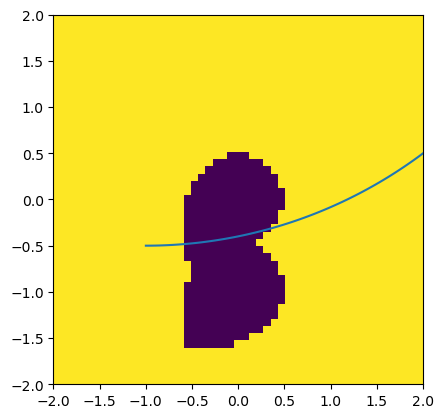

In [255]:
# Animate
import matplotlib.animation as animation

fig, ax = plt.subplots()
img = ax.imshow(value_func.val_grid[:, :, 0].T>0, origin='lower', extent=[-2, 2, -2, 2])
line, = ax.plot([], [])

def animate(k):
    theta_idx = value_func.theta_to_grid(states[k, 2])
    img.set_array(value_func.val_grid[:, :, theta_idx].T>0) #update the image data.
    line.set_data(states[:k, 0], states[:k, 1])
    return img, line,

ani = animation.FuncAnimation(fig, animate, frames=states.shape[0], interval=200, blit=True) #adjust interval

ani.save('reachability_animation.gif')  # Save as GIF

In [256]:
import v_func_utils
importlib.reload(v_func_utils)
from v_func_utils import get_spatial_grad

print([value_func.V(states[k, :]) for k in range(len(states))])
print([get_spatial_grad(value_func.V, states[k, :])[2] for k in range(len(states))])
states[2, :]


[0.024863068014383316, 0.0008591994410380721, -0.00916596595197916, -0.014792261645197868, -0.016951296478509903, -0.017030060291290283, -0.01697435975074768, -0.016784803941845894, -0.016542037948966026, -0.016276150941848755, -0.017728332430124283, -0.020435836166143417, -0.024768926203250885, -0.03220552206039429, -0.04210127890110016, -0.05406488850712776, -0.06634219735860825, -0.0790436863899231, -0.08977355062961578, -0.09885235130786896, -0.10585395991802216, -0.10860350728034973, -0.10903104394674301, -0.10443601757287979, -0.09475254267454147, -0.08108789473772049, -0.06082163751125336, -0.03799549862742424, -0.01005622185766697, 0.02057068422436714, 0.053075749427080154, 0.08796778321266174, 0.1238861232995987, 0.16214898228645325, 0.2018515169620514, 0.24213027954101562, 0.28300100564956665, 0.3241705000400543, 0.3671584129333496, 0.4103761315345764, 0.4536493420600891, 0.49694180488586426, 0.5413193106651306, 0.5860080718994141, 0.6305380463600159, 0.6749041080474854, 0.72

tensor([-0.9000, -0.4990,  0.0200])

In [308]:
# Simulate with safety
N = 100
dt = 0.1
actions = torch.zeros(N, 1)
values = torch.zeros(N, 1)
states = torch.zeros(N, 3)
states[0,:] = torch.tensor([-1.5, -0.5, 0])

eps = 0.1
for k in range(0, N-1):
    values[k, 0] = value_func.V(states[k, :])
    if values[k, 0] <= eps:
        _, _, pz = get_spatial_grad(value_func.V, states[k, :])
        if pz < 0:
            actions[k, 0] = -2
        else:
            actions[k, 0] = 2
    else:
        actions[k, 0] = max(-1, min(1, -dubins.state_error(states[k, :], states[0, :])[2]*100))
    states[k +1:k+2, :] = dubins.discrete_rk4(states[k:k+1, :], actions[k:k+1, :], dt)



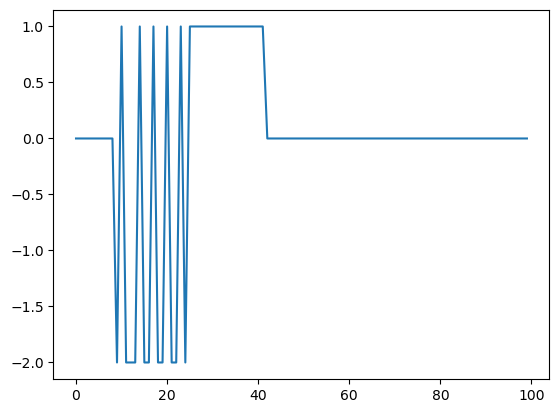

In [309]:
plt.plot(actions)

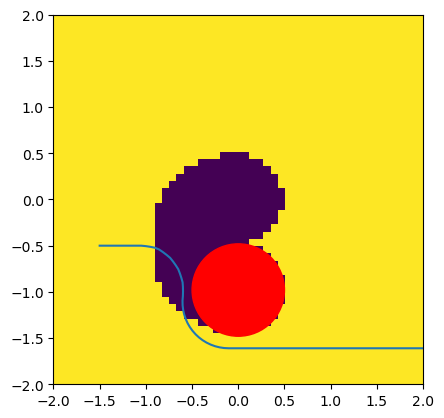

In [310]:
# Animate
import matplotlib.animation as animation
import matplotlib.patches as patches

fig, ax = plt.subplots()
img = ax.imshow(value_func.val_grid[:, :, 0].T>0, origin='lower', extent=[-2, 2, -2, 2])
circ1 = patches.Circle((x_c, y_c), radius=radius, facecolor='red', edgecolor='red')
ax.add_patch(circ1)
# obstacle1 = jnp.linalg.norm(np.array([0.0, 0.0]) - value_func.grid.states[..., :2], axis=-1) - radius
# obstacle2 = jnp.linalg.norm(np.array([x_c, y_c]) - value_func.grid.states[..., :2] , axis=-1) - radius
line, = ax.plot([], [])

def animate(k):
    theta_idx = value_func.theta_to_grid(states[k, 2])
    img.set_array(value_func.val_grid[:, :, theta_idx].T>0) #update the image data.
    line.set_data(states[:k, 0], states[:k, 1])
    return img, line,

ani = animation.FuncAnimation(fig, animate, frames=states.shape[0], interval=200, blit=True) #adjust interval

ani.save('reachability_animation.gif')  # Save as GIF

array([ 0. ,  0. , -0.1])